In [ ]:
#Part 1 Problem Definition and Data Collection

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv( r"C:\Users\DELL\Downloads\housingdatafinal.csv")
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')

print(df.shape)
df.head()

(101, 18)


,property_id,address,suburb,postcode,property_type,sale_price,price_disclosed,sale_date,bedrooms,bathrooms,car_spaces,land_size_sqm,listed_area_sqm,suburb_population,suburb_median_household_income_annual,agent_name,agent_company,notes
0,1,8/88 Avenue Road,Mosman,2088,unit,730000.0,Yes,2026-09-12,1,1,1,NaN,NaN,28329,150384,Mitchell Soineva,Pello Lower North Shore,NaN
1,2,7/10 Muston Street,Mosman,2088,unit,750000.0,Yes,2026-09-08,1,1,0,NaN,45.0,28329,150384,Titan Davis,Pello Lower North Shore,"land_size is the whole strata lot, not a priva..."
2,3,13/5 The Esplanade,Mosman,2088,unit,1450000.0,Yes,2026-09-03,1,1,0,NaN,NaN,28329,150384,Samuel Petrou,Ray White Lower North Shore Group,NaN
3,4,8/73 Spit Road,Mosman,2088,unit,NaN,No,2026-09-10,2,1,1,NaN,107.0,28329,150384,Adam Vernon,Vernon Partners,"PRICE WITHHELD - exclude from model training, ..."
4,5,2B Mosman Street,Mosman,2088,house,NaN,No,2026-09-09,3,2,1,NaN,NaN,28329,150384,David Grant,De Brennan Property,PRICE WITHHELD - notable architectural heritag...


In [5]:
df.groupby('suburb')[['suburb_population', 'suburb_median_household_income_annual']].first()

,suburb_population,suburb_median_household_income_annual
suburb,,
Mosman,28329,150384
Mount Druitt,16986,76856
Parramatta,30211,108784


In [7]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("Price disclosure:")
print(df['price_disclosed'].value_counts())
print()
print("Property type by suburb:")
print(pd.crosstab(df['suburb'], df['property_type']))

Missing values per column:
sale_price         16
sale_date           3
land_size_sqm      87
listed_area_sqm    87
agent_name         32
agent_company      11
notes              72
dtype: int64

Price disclosure:
price_disclosed
Yes    85
No     16
Name: count, dtype: int64

Property type by suburb:
property_type  house  retirement  semi-detached  townhouse  unit  villa
suburb                                                                 
Mosman             7           1              1          0    27      0
Mount Druitt      10           0              1          3    12      4
Parramatta         1           0              0          0    33      1


In [9]:
#Part 2: Data Understanding and Feature Engineering----------------------------------------------------------
##

In [11]:
unreliable_area = df['notes'].fillna('').str.contains('strata block|whole strata lot|whole allotment', case=False)
df['listed_area_clean'] = df['listed_area_sqm'].where(~unreliable_area)
df['land_size_clean'] = df['land_size_sqm'].where(~unreliable_area)

print(f"{unreliable_area.sum()} rows had area figures flagged as unreliable and nulled out")

disclosed = df[df['price_disclosed'] == 'Yes'].copy()
print(f"{len(disclosed)} of {len(df)} properties have a disclosed price and are used for the analysis below")

4 rows had area figures flagged as unreliable and nulled out
85 of 101 properties have a disclosed price and are used for the analysis below


In [13]:
#Price distribution and suburb comparison
disclosed.groupby('suburb')['sale_price'].agg(['count', 'median', 'mean', 'std']).round(0)

,count,median,mean,std
suburb,,,,
Mosman,20,1012500.0,1789500.0,1846754.0
Mount Druitt,30,650850.0,733723.0,354630.0
Parramatta,35,570000.0,623829.0,311651.0


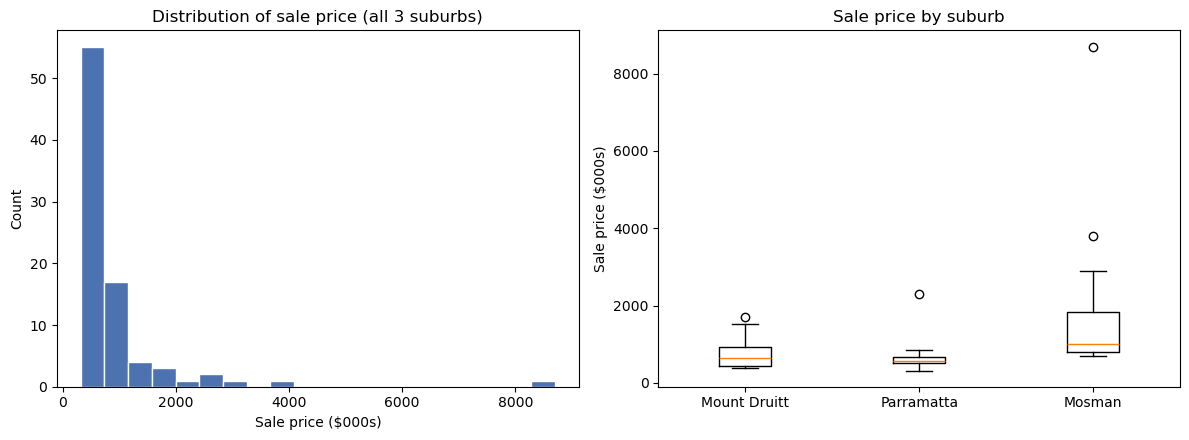

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(disclosed['sale_price'] / 1000, bins=20, color='#4C72B0', edgecolor='white')
axes[0].set_xlabel('Sale price ($000s)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of sale price (all 3 suburbs)')

order = ['Mount Druitt', 'Parramatta', 'Mosman']
data_by_suburb = [disclosed[disclosed['suburb'] == s]['sale_price'] / 1000 for s in order]
axes[1].boxplot(data_by_suburb, labels=order)
axes[1].set_ylabel('Sale price ($000s)')
axes[1].set_title('Sale price by suburb')

plt.tight_layout()
plt.show()

property_type  house  retirement  semi-detached  townhouse  unit  villa
suburb                                                                 
Mosman             7           1              1          0    27      0
Mount Druitt      10           0              1          3    12      4
Parramatta         1           0              0          0    33      1


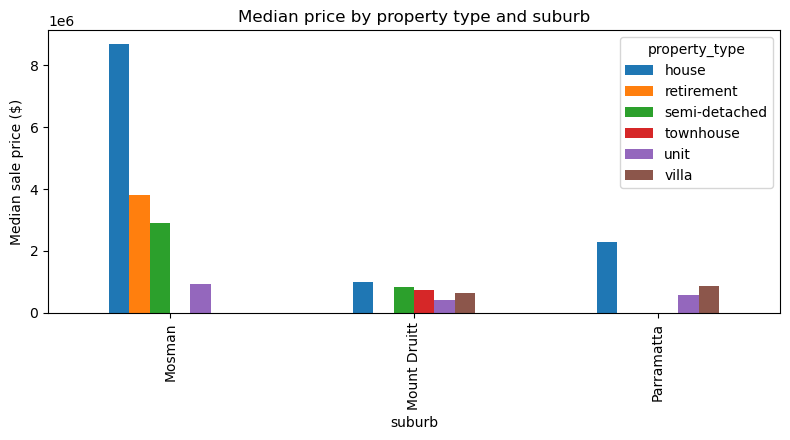

In [17]:
print(pd.crosstab(df['suburb'], df['property_type']))

# median price for each suburb + property type combo
pivot = disclosed.groupby(['suburb', 'property_type'])['sale_price'].median().unstack()

fig, ax = plt.subplots(figsize=(8, 4.5))
pivot.plot(kind='bar', ax=ax)
ax.set_ylabel('Median sale price ($)')
ax.set_title('Median price by property type and suburb')
plt.tight_layout()
plt.show()

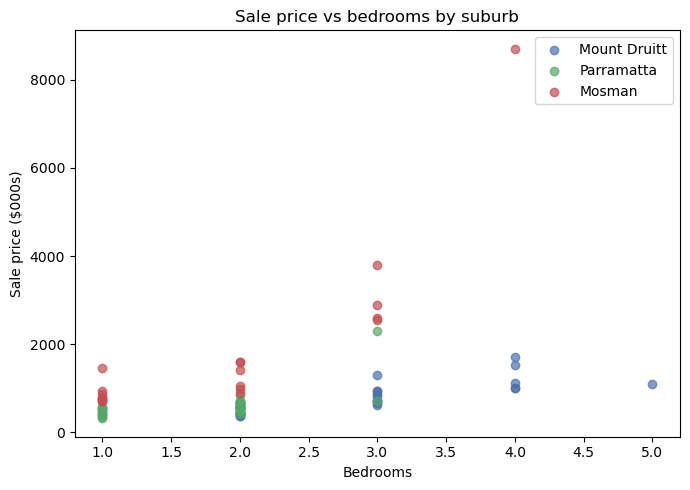

In [19]:
#Price vs bedrooms, and trend over time
fig, ax = plt.subplots(figsize=(7, 5))
colors = {'Mosman': '#C44E52', 'Parramatta': '#55A868', 'Mount Druitt': '#4C72B0'}
for s in order:
    sub = disclosed[disclosed['suburb'] == s]
    ax.scatter(sub['bedrooms'], sub['sale_price'] / 1000, label=s, alpha=0.7, color=colors[s])
ax.set_xlabel('Bedrooms')
ax.set_ylabel('Sale price ($000s)')
ax.set_title('Sale price vs bedrooms by suburb')
ax.legend()
plt.tight_layout()
plt.show()

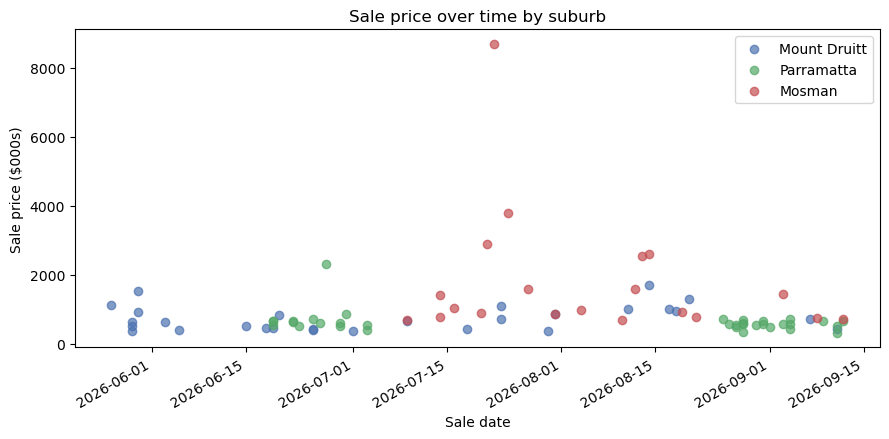

In [21]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for s in order:
    sub = disclosed[disclosed['suburb'] == s].dropna(subset=['sale_date'])
    ax.scatter(sub['sale_date'], sub['sale_price'] / 1000, label=s, alpha=0.7, color=colors[s])
ax.set_xlabel('Sale date')
ax.set_ylabel('Sale price ($000s)')
ax.set_title('Sale price over time by suburb')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [23]:
#Outlier Detectioning
def iqr_outliers(group):
    q1, q3 = group['sale_price'].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return group[(group['sale_price'] < lower) | (group['sale_price'] > upper)]

outliers = disclosed.groupby('suburb', group_keys=False)[disclosed.columns].apply(iqr_outliers)
outliers[['suburb', 'property_type', 'bedrooms', 'sale_price', 'notes']]

,suburb,property_type,bedrooms,sale_price,notes
14,Mosman,retirement,3,3800000.0,Listed as 'Retirement Living' category - high ...
15,Mosman,house,4,8700000.0,Highest price collected so far - flag as poten...
76,Mount Druitt,townhouse,4,1700000.0,NaN
61,Parramatta,house,3,2300000.0,NaN


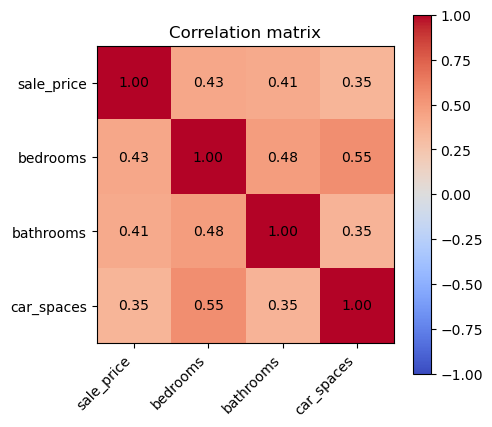

In [25]:
#Correlation between numeric features and price
fig, ax = plt.subplots(figsize=(5, 4.5))
corr_cols = ['sale_price', 'bedrooms', 'bathrooms', 'car_spaces']
corr = disclosed[corr_cols].corr()
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
plt.colorbar(im)
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()

In [27]:
#Part 3 Model Development and Evaluation---------------------------------------------------------

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score



# only keep properties where we actually know the sale price (see Part 1)
disclosed = df[df['price_disclosed'] == 'Yes'].copy()

# villa/townhouse/semi-detached/retirement only have a handful of rows each,
# so lump them into "other" - otherwise one-hot encoding creates categories
# that might not even show up in every CV fold
disclosed['property_type_grouped'] = disclosed['property_type'].where(
    disclosed['property_type'].isin(['unit', 'house']), 'other'
)

print(len(disclosed), "properties going into modelling")
disclosed['property_type_grouped'].value_counts()

85 properties going into modelling


property_type_grouped
unit     62
house    12
other    11
Name: count, dtype: int64

In [31]:
X = pd.get_dummies(
    disclosed[['suburb', 'property_type_grouped', 'bedrooms', 'bathrooms', 'car_spaces']],
    columns=['suburb', 'property_type_grouped']
)
y = disclosed['sale_price'].values
y_log = np.log1p(y)
suburb_col = disclosed['suburb'].values

X.head()

,bedrooms,bathrooms,car_spaces,suburb_Mosman,suburb_Mount Druitt,suburb_Parramatta,property_type_grouped_house,property_type_grouped_other,property_type_grouped_unit
0,1,1,1,True,False,False,False,False,True
1,1,1,0,True,False,False,False,False,True
2,1,1,0,True,False,False,False,False,True
5,1,1,0,True,False,False,False,False,True
6,1,1,1,True,False,False,False,False,True


In [33]:
def mae_dollars(y_true_log, y_pred_log):
    return mean_absolute_error(np.expm1(y_true_log), np.expm1(y_pred_log))

def rmse_dollars(y_true_log, y_pred_log):
    return np.sqrt(mean_squared_error(np.expm1(y_true_log), np.expm1(y_pred_log)))

def r2_dollars(y_true_log, y_pred_log):
    return r2_score(np.expm1(y_true_log), np.expm1(y_pred_log))

scoring = {
    'MAE': make_scorer(mae_dollars, greater_is_better=False),
    'RMSE': make_scorer(rmse_dollars, greater_is_better=False),
    'R2': make_scorer(r2_dollars),
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [35]:
lr_scores = cross_validate(LinearRegression(), X, y_log, cv=kf.split(X, suburb_col), scoring=scoring)
print(f"Linear Regression:  MAE ${-lr_scores['test_MAE'].mean():,.0f}  RMSE ${-lr_scores['test_RMSE'].mean():,.0f}  R2 {lr_scores['test_R2'].mean():.3f}")

rf_scores = cross_validate(RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=3, random_state=42),
                            X, y_log, cv=kf.split(X, suburb_col), scoring=scoring)
print(f"Random Forest:      MAE ${-rf_scores['test_MAE'].mean():,.0f}  RMSE ${-rf_scores['test_RMSE'].mean():,.0f}  R2 {rf_scores['test_R2'].mean():.3f}")

svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1))
])
svr_scores = cross_validate(svr_pipeline, X, y_log, cv=kf.split(X, suburb_col), scoring=scoring)
print(f"SVR (RBF):          MAE ${-svr_scores['test_MAE'].mean():,.0f}  RMSE ${-svr_scores['test_RMSE'].mean():,.0f}  R2 {svr_scores['test_R2'].mean():.3f}")

Linear Regression:  MAE $207,971  RMSE $384,936  R2 0.794
Random Forest:      MAE $272,030  RMSE $625,239  R2 0.466
SVR (RBF):          MAE $239,269  RMSE $594,112  R2 0.599


In [37]:
print("Random Forest - trying a few max_depth / min_samples_leaf combos:")
best_rf_mae = None
best_rf_params = None
for depth in [5, 8, None]:
    for leaf in [1, 3, 5]:
        model = RandomForestRegressor(n_estimators=200, max_depth=depth, min_samples_leaf=leaf, random_state=42)
        scores = cross_validate(model, X, y_log, cv=kf.split(X, suburb_col), scoring=scoring)
        mae = -scores['test_MAE'].mean()
        print(f"  max_depth={depth}, min_samples_leaf={leaf} -> MAE ${mae:,.0f}")
        if best_rf_mae is None or mae < best_rf_mae:
            best_rf_mae = mae
            best_rf_params = (depth, leaf)

print("\nBest RF params:", best_rf_params)

Random Forest - trying a few max_depth / min_samples_leaf combos:
  max_depth=5, min_samples_leaf=1 -> MAE $227,929
  max_depth=5, min_samples_leaf=3 -> MAE $271,456
  max_depth=5, min_samples_leaf=5 -> MAE $307,749
  max_depth=8, min_samples_leaf=1 -> MAE $229,100
  max_depth=8, min_samples_leaf=3 -> MAE $270,719
  max_depth=8, min_samples_leaf=5 -> MAE $307,742
  max_depth=None, min_samples_leaf=1 -> MAE $229,351
  max_depth=None, min_samples_leaf=3 -> MAE $270,719
  max_depth=None, min_samples_leaf=5 -> MAE $307,742

Best RF params: (5, 1)


In [38]:
print("SVR - trying a few C / gamma combos:")
best_svr_mae = None
best_svr_params = None
for C in [1, 10, 50]:
    for gamma in ['scale', 0.01, 0.1]:
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('svr', SVR(kernel='rbf', C=C, gamma=gamma, epsilon=0.1))
        ])
        scores = cross_validate(model, X, y_log, cv=kf.split(X, suburb_col), scoring=scoring)
        mae = -scores['test_MAE'].mean()
        print(f"  C={C}, gamma={gamma} -> MAE ${mae:,.0f}")
        if best_svr_mae is None or mae < best_svr_mae:
            best_svr_mae = mae
            best_svr_params = (C, gamma)

print("\nBest SVR params:", best_svr_params)

SVR - trying a few C / gamma combos:
  C=1, gamma=scale -> MAE $239,269
  C=1, gamma=0.01 -> MAE $265,270
  C=1, gamma=0.1 -> MAE $236,108
  C=10, gamma=scale -> MAE $240,505
  C=10, gamma=0.01 -> MAE $196,758
  C=10, gamma=0.1 -> MAE $233,781
  C=50, gamma=scale -> MAE $240,522
  C=50, gamma=0.01 -> MAE $205,217
  C=50, gamma=0.1 -> MAE $233,792

Best SVR params: (10, 0.01)


In [39]:
final_rf = RandomForestRegressor(n_estimators=200, max_depth=best_rf_params[0], min_samples_leaf=best_rf_params[1], random_state=42)
final_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=best_svr_params[0], gamma=best_svr_params[1], epsilon=0.1))
])

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest (tuned)': final_rf,
    'SVR RBF (tuned)': final_svr,
}

results = {}
for name, model in models.items():
    scores = cross_validate(model, X, y_log, cv=kf.split(X, suburb_col), scoring=scoring)
    results[name] = {
        'CV MAE': -scores['test_MAE'].mean(),
        'MAE std': scores['test_MAE'].std(),
        'CV RMSE': -scores['test_RMSE'].mean(),
        'CV R2': scores['test_R2'].mean(),
    }

results_df = pd.DataFrame(results).T.round(2)
results_df

,CV MAE,MAE std,CV RMSE,CV R2
Linear Regression,207971.09,95177.39,384935.78,0.79
Random Forest (tuned),227928.84,98274.24,525674.44,0.57
SVR RBF (tuned),196758.27,112045.51,435434.01,0.72


In [40]:
##Comparison table
final_rf = RandomForestRegressor(n_estimators=200, max_depth=best_rf_params[0], min_samples_leaf=best_rf_params[1], random_state=42)
final_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=best_svr_params[0], gamma=best_svr_params[1], epsilon=0.1))
])

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest (tuned)': final_rf,
    'SVR RBF (tuned)': final_svr,
}

results = {}
for name, model in models.items():
    scores = cross_validate(model, X, y_log, cv=kf.split(X, suburb_col), scoring=scoring)
    results[name] = {
        'CV MAE': -scores['test_MAE'].mean(),
        'MAE std': scores['test_MAE'].std(),
        'CV RMSE': -scores['test_RMSE'].mean(),
        'CV R2': scores['test_R2'].mean(),
    }

results_df = pd.DataFrame(results).T.round(2)
results_df

,CV MAE,MAE std,CV RMSE,CV R2
Linear Regression,207971.09,95177.39,384935.78,0.79
Random Forest (tuned),227928.84,98274.24,525674.44,0.57
SVR RBF (tuned),196758.27,112045.51,435434.01,0.72


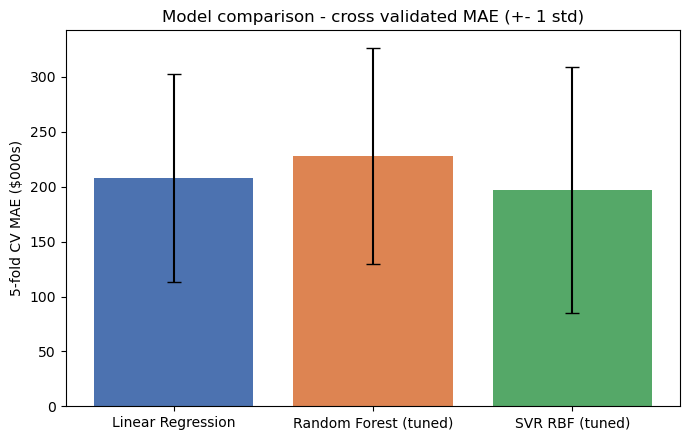

In [41]:
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(results_df.index, results_df['CV MAE']/1000, yerr=results_df['MAE std']/1000, capsize=5,
       color=['#4C72B0','#DD8452','#55A868'])
ax.set_ylabel('5-fold CV MAE ($000s)')
ax.set_title('Model comparison - cross validated MAE (+- 1 std)')
plt.tight_layout()
plt.show()

In [44]:
for name, model in models.items():
    model.fit(X, y_log)
    train_pred = np.expm1(model.predict(X))
    train_mae = mean_absolute_error(y, train_pred)
    cv_mae = results_df.loc[name, 'CV MAE']
    gap = 100 * (cv_mae - train_mae) / train_mae
    print(f"{name:25s} train MAE ${train_mae:,.0f}   CV MAE ${cv_mae:,.0f}   gap {gap:.0f}%")

Linear Regression         train MAE $192,725   CV MAE $207,971   gap 8%
Random Forest (tuned)     train MAE $130,048   CV MAE $227,929   gap 75%
SVR RBF (tuned)           train MAE $126,505   CV MAE $196,758   gap 56%


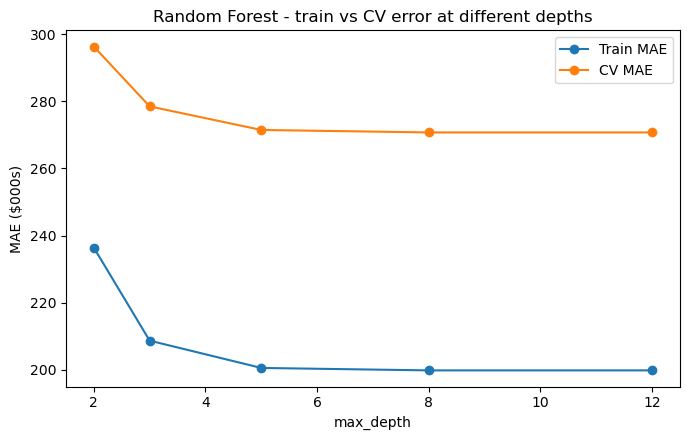

In [45]:
depths = [2, 3, 5, 8, 12]
train_maes = []
cv_maes = []

for depth in depths:
    model = RandomForestRegressor(n_estimators=200, max_depth=depth, min_samples_leaf=3, random_state=42)
    scores = cross_validate(model, X, y_log, cv=kf.split(X, suburb_col), scoring=scoring)
    cv_maes.append(-scores['test_MAE'].mean())
    model.fit(X, y_log)
    train_pred = np.expm1(model.predict(X))
    train_maes.append(mean_absolute_error(y, train_pred))

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(depths, np.array(train_maes)/1000, marker='o', label='Train MAE')
ax.plot(depths, np.array(cv_maes)/1000, marker='o', label='CV MAE')
ax.set_xlabel('max_depth')
ax.set_ylabel('MAE ($000s)')
ax.set_title('Random Forest - train vs CV error at different depths')
ax.legend()
plt.tight_layout()
plt.show()

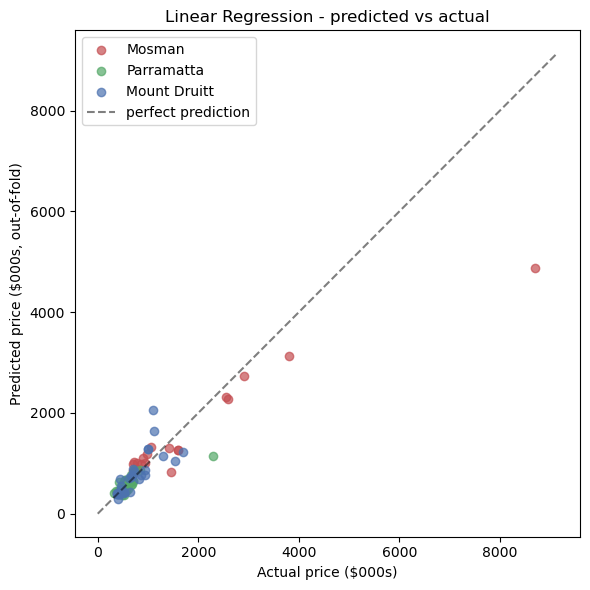

In [47]:
oof_pred_log = cross_val_predict(LinearRegression(), X, y_log, cv=kf.split(X, suburb_col))
oof_pred = np.expm1(oof_pred_log)

fig, ax = plt.subplots(figsize=(6,6))
colors = {'Mosman':'#C44E52','Parramatta':'#55A868','Mount Druitt':'#4C72B0'}
for s in colors:
    mask = suburb_col == s
    ax.scatter(y[mask]/1000, oof_pred[mask]/1000, alpha=0.7, color=colors[s], label=s)
lims = [0, max(y.max(), oof_pred.max())/1000 * 1.05]
ax.plot(lims, lims, 'k--', alpha=0.5, label='perfect prediction')
ax.set_xlabel('Actual price ($000s)')
ax.set_ylabel('Predicted price ($000s, out-of-fold)')
ax.set_title('Linear Regression - predicted vs actual')
ax.legend()
plt.tight_layout()
plt.show()

In [48]:
#Part 4  Investigating Prediction Failures------------------------------------------------------------------------------------

In [49]:
# reusing 'oof_pred' from Part 3 above - it's already the out-of-fold prediction
# for every property from the Linear Regression model, so no need to refit anything here
disclosed['predicted_price'] = oof_pred

# error = predicted minus actual, so a positive number means the model
# guessed TOO HIGH, and a negative number means it guessed too low
disclosed['error'] = disclosed['predicted_price'] - disclosed['sale_price']
disclosed['abs_error'] = disclosed['error'].abs()

# $ error alone can be misleading (a $600k miss means very different things
# on a $1.5M property vs an $8M one), so also work out error as a % of the actual price
disclosed['pct_error'] = 100 * disclosed['abs_error'] / disclosed['sale_price']

In [52]:
top5 = disclosed.sort_values('abs_error', ascending=False).head(5)

cols_to_show = ['suburb', 'property_type', 'bedrooms', 'bathrooms', 'car_spaces',
                 'sale_price', 'predicted_price', 'error', 'pct_error', 'notes']
top5[cols_to_show]

,suburb,property_type,bedrooms,bathrooms,car_spaces,sale_price,predicted_price,error,pct_error,notes
15,Mosman,house,4,3,2,8700000.0,4.878762e+06,-3.821238e+06,43.922279,Highest price collected so far - flag as poten...
61,Parramatta,house,3,1,1,2300000.0,1.142434e+06,-1.157566e+06,50.328949,NaN
81,Mount Druitt,house,5,2,2,1105000.0,2.058198e+06,9.531979e+05,86.262249,Combined/dual-address sale (2 titles sold toge...
14,Mosman,retirement,3,2,2,3800000.0,3.132634e+06,-6.673664e+05,17.562274,Listed as 'Retirement Living' category - high ...
2,Mosman,unit,1,1,0,1450000.0,8.302044e+05,-6.197956e+05,42.744525,NaN


In [54]:
# this shows how many of each grouped property type exist per suburb,so I can check whether any of the top-5 error properties are an unusual
# type for their suburb (which would make sense the model struggles with them -
# it hasn't seen many examples like that to learn from)
pd.crosstab(disclosed['suburb'], disclosed['property_type_grouped'])

property_type_grouped,house,other,unit
suburb,,,
Mosman,1,2,17
Mount Druitt,10,8,12
Parramatta,1,1,33


In [55]:
#Part 5 Human Judgement, Machine Learning, and Large Language Models

In [67]:

held_out_ids = [18, 7, 77, 100, 84, 91, 44, 60, 47, 65]

test_data = disclosed[disclosed['property_id'].isin(held_out_ids)].copy()
train_data = disclosed[~disclosed['property_id'].isin(held_out_ids)].copy()

print(test_data[['property_id', 'suburb', 'property_type', 'bedrooms', 'bathrooms', 'car_spaces', 'sale_price']])

    property_id        suburb property_type  bedrooms  bathrooms  car_spaces  \
6             7        Mosman          unit         1          1           1   
17           18        Mosman          unit         2          1           0   
43           44    Parramatta          unit         2          2           1   
46           47    Parramatta          unit         2          1           1   
59           60    Parramatta          unit         1          1           0   
64           65    Parramatta          unit         2          2           1   
76           77  Mount Druitt     townhouse         4          2           2   
83           84  Mount Druitt          unit         2          1           1   
90           91  Mount Druitt         villa         2          1           1   
99          100  Mount Druitt         house         4          3           2   

    sale_price  
6     930000.0  
17    892000.0  
43    570000.0  
46    650000.0  
59    520000.0  
64    710000.0  


In [69]:
from sklearn.linear_model import LinearRegression


X_train = pd.get_dummies(
    train_data[['suburb', 'property_type_grouped', 'bedrooms', 'bathrooms', 'car_spaces']],
    columns=['suburb', 'property_type_grouped']
)
y_train = np.log1p(train_data['sale_price'])

model = LinearRegression()
model.fit(X_train, y_train)

# predict on the 10 held-out properties - genuinely unseen by this model
X_test = pd.get_dummies(
    test_data[['suburb', 'property_type_grouped', 'bedrooms', 'bathrooms', 'car_spaces']],
    columns=['suburb', 'property_type_grouped']
)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)  # match dummy columns to training set

ml_predictions = np.expm1(model.predict(X_test))

results = test_data[['property_id', 'suburb', 'property_type', 'sale_price']].copy()
results['ml_prediction'] = ml_predictions.round(0)
print(results)

    property_id        suburb property_type  sale_price  ml_prediction
6             7        Mosman          unit    930000.0      1021318.0
17           18        Mosman          unit    892000.0      1126522.0
43           44    Parramatta          unit    570000.0       646593.0
46           47    Parramatta          unit    650000.0       581115.0
59           60    Parramatta          unit    520000.0       381994.0
64           65    Parramatta          unit    710000.0       646593.0
76           77  Mount Druitt     townhouse   1700000.0      1175549.0
83           84  Mount Druitt          unit    435000.0       387345.0
90           91  Mount Druitt         villa    465000.0       536135.0
99          100  Mount Druitt         house   1125000.0      1639595.0


In [71]:
from sklearn.metrics import mean_absolute_error


held_out_ids = [18, 7, 77, 100, 84, 91, 44, 60, 47, 65]
results = results.set_index('property_id').loc[held_out_ids].reset_index()

results['llm_estimate'] = [1000000, 900000, 800000, 900000, 500000, 550000, 700000, 450000, 600000, 680000]
results['my_estimate'] = [900000, 951318, 1020000, 1450000, 550000, 650000, 550000, 500000, 500000, 690000]

print(results)
print()
print("ML MAE:", mean_absolute_error(results['sale_price'], results['ml_prediction']))
print("LLM MAE:", mean_absolute_error(results['sale_price'], results['llm_estimate']))
print("My MAE:", mean_absolute_error(results['sale_price'], results['my_estimate']))

   property_id        suburb property_type  sale_price  ml_prediction  \
0           18        Mosman          unit    892000.0      1126522.0   
1            7        Mosman          unit    930000.0      1021318.0   
2           77  Mount Druitt     townhouse   1700000.0      1175549.0   
3          100  Mount Druitt         house   1125000.0      1639595.0   
4           84  Mount Druitt          unit    435000.0       387345.0   
5           91  Mount Druitt         villa    465000.0       536135.0   
6           44    Parramatta          unit    570000.0       646593.0   
7           60    Parramatta          unit    520000.0       381994.0   
8           47    Parramatta          unit    650000.0       581115.0   
9           65    Parramatta          unit    710000.0       646593.0   

   llm_estimate  my_estimate  
0       1000000       900000  
1        900000       951318  
2        800000      1020000  
3        900000      1450000  
4        500000       550000  
5        5